**Initialize**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

col = ['time', 'long', 'x', 'y', 'z']
r_k = pd.read_csv('KAMOOALEWA.aei', sep='\s+', skiprows=4, names=col)
r_f = pd.read_csv('2023FW13.aei', sep='\s+', skiprows=4, names=col)
r_e = pd.read_csv('EARTH.aei', sep='\s+', skiprows=4, names=col)
r_a = pd.read_csv('APOPHIS.aei', sep='\s+', skiprows=4, names=col)

**ICRF**

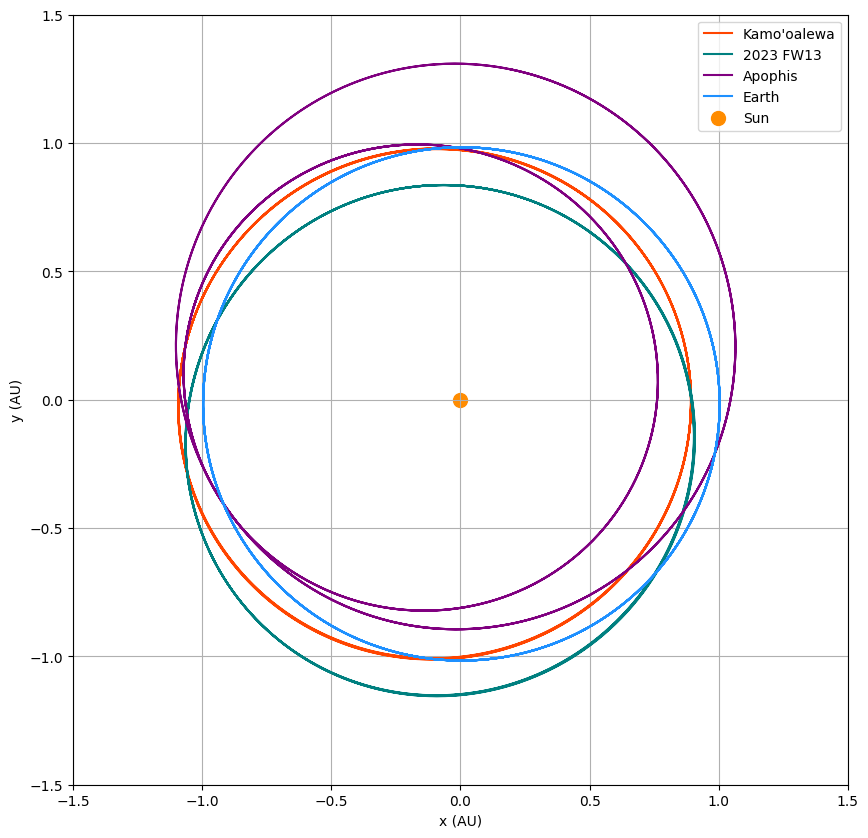

In [2]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(r_k['x'], r_k['y'], label='Kamo\'oalewa', color='orangered')
ax.plot(r_f['x'], r_f['y'], label='2023 FW13', color='teal')
ax.plot(r_a['x'], r_a['y'], label='Apophis', color='purple')
ax.plot(r_e['x'], r_e['y'], label='Earth', color='dodgerblue')
ax.scatter(0, 0, color='darkorange', s=100, label='Sun')

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True)
plt.show()

**Earth-centric coordinates**

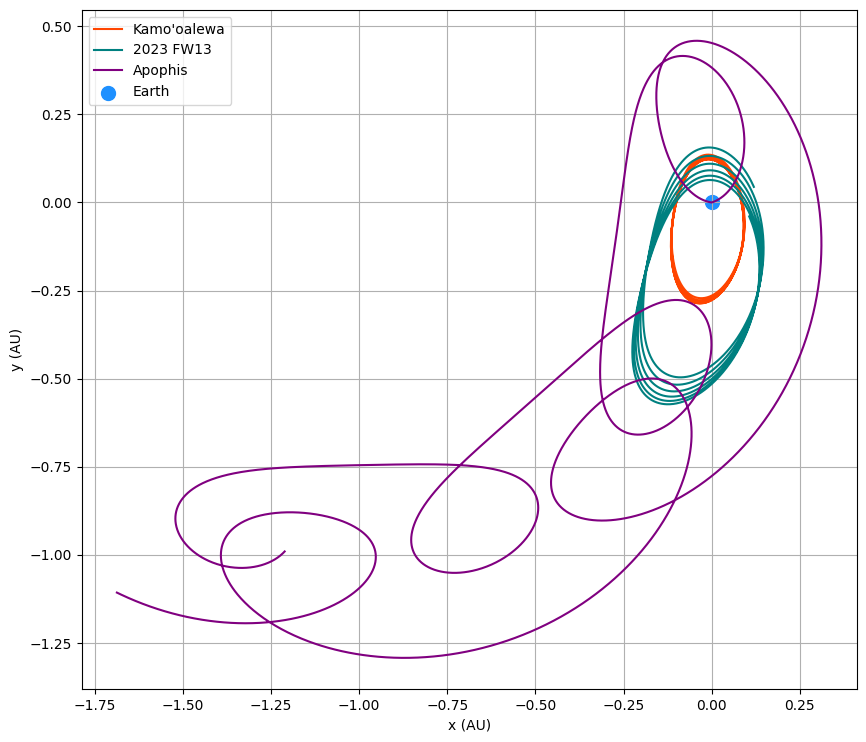

In [10]:
theta = np.arctan2(r_e['y'], r_e['x'])

x_k_rot = r_k['x'] * np.cos(theta) + r_k['y'] * np.sin(theta) - (r_e['x'] * np.cos(theta) + r_e['y'] * np.sin(theta))
y_k_rot = -r_k['x'] * np.sin(theta) + r_k['y'] * np.cos(theta) - (-r_e['x'] * np.sin(theta) + r_e['y'] * np.cos(theta))

x_f_rot = r_f['x'] * np.cos(theta) + r_f['y'] * np.sin(theta) - (r_e['x'] * np.cos(theta) + r_e['y'] * np.sin(theta))
y_f_rot = -r_f['x'] * np.sin(theta) + r_f['y'] * np.cos(theta) - (-r_e['x'] * np.sin(theta) + r_e['y'] * np.cos(theta))

x_a_rot = r_a['x'] * np.cos(theta) + r_a['y'] * np.sin(theta) - (r_e['x'] * np.cos(theta) + r_e['y'] * np.sin(theta))
y_a_rot = -r_a['x'] * np.sin(theta) + r_a['y'] * np.cos(theta) - (-r_e['x'] * np.sin(theta) + r_e['y'] * np.cos(theta))

fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(x_k_rot, y_k_rot, label='Kamo\'oalewa', color='orangered')
ax.plot(x_f_rot, y_f_rot, label='2023 FW13', color='teal')
ax.plot(x_a_rot, y_a_rot, label='Apophis', color='purple')
ax.scatter(0, 0, label='Earth', color='dodgerblue', s=100)

ax.set_aspect('equal')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True)
plt.show()

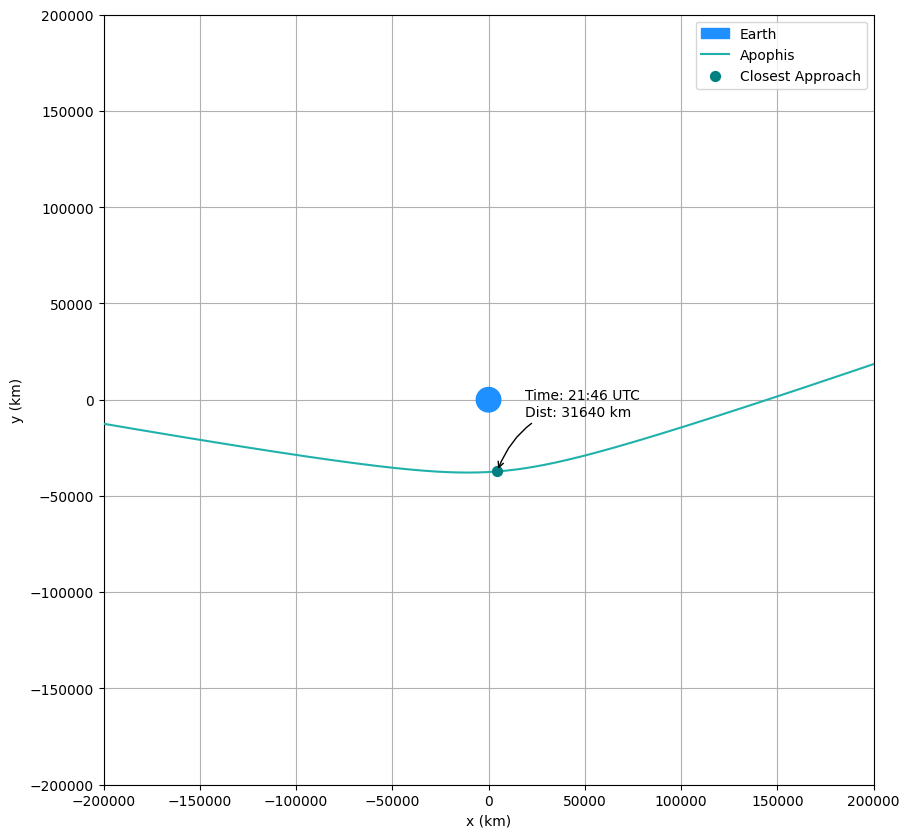

In [41]:
r_a_enc = pd.read_csv('../Apophis_encounter/APOPHIS.aei', sep='\s+', skiprows=4, names=col)
r_e_enc = pd.read_csv('../Apophis_encounter/EARTH.aei', sep='\s+', skiprows=4, names=col)

theta_enc = np.arctan2(r_e_enc['y'], r_e_enc['x'])

AUtoKM = 149597870.7
x_a_rot_enc = (r_a_enc['x'] * np.cos(theta_enc) + r_a_enc['y'] * np.sin(theta_enc) - (r_e_enc['x'] * np.cos(theta_enc) + r_e_enc['y'] * np.sin(theta_enc)))*AUtoKM
y_a_rot_enc = (-r_a_enc['x'] * np.sin(theta_enc) + r_a_enc['y'] * np.cos(theta_enc) - (-r_e_enc['x'] * np.sin(theta_enc) + r_e_enc['y'] * np.cos(theta_enc)))*AUtoKM
z_a_rot_enc = (r_a_enc['z'] - r_e_enc['z'])*AUtoKM

enc_dist = np.sqrt(x_a_rot_enc**2 + y_a_rot_enc**2 + z_a_rot_enc**2)
min_idx = enc_dist.idxmin()
closest_x = x_a_rot_enc[min_idx]
closest_y = y_a_rot_enc[min_idx]
closest_z = z_a_rot_enc[min_idx]
min_dist = enc_dist[min_idx]-6371
min_time = r_a_enc['time'][min_idx]
hour = int(min_time * 24)
minute = int((min_time * 24 - hour) * 60)
time_str = f"{hour:02d}:{minute:02d} UTC"

fig, ax = plt.subplots(figsize=(10, 10))

earth = plt.Circle((0, 0), 6371, color='dodgerblue', label='Earth', zorder=3)
ax.add_patch(earth)

ax.plot(x_a_rot_enc, y_a_rot_enc, label='Apophis', color='lightseagreen', zorder=4)
ax.scatter(closest_x, closest_y, label='Closest Approach', color='teal', s=50, zorder=5)

label_text = f"Time: {time_str}\nDist: {min_dist:.0f} km"
ax.annotate(label_text,
            xy=(closest_x, closest_y),
            xytext=(20, 40),
            textcoords='offset points',
            fontsize=10,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='black'),
            zorder=6)

ax.set_aspect('equal')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.legend()
ax.grid(True)

zoom_limit = 200000
ax.set_xlim(-zoom_limit, zoom_limit)
ax.set_ylim(-zoom_limit, zoom_limit)

plt.show()

**HORIZONS Data**

In [26]:
from astroquery.jplhorizons import Horizons
from astropy.time import Time

start_jd = 2461143.5
duration_years = 1
stop_jd = start_jd + (duration_years * 365.25)

start_iso = Time(start_jd, format='jd').iso.split()[0]
stop_iso = Time(stop_jd, format='jd').iso.split()[0]

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '10d'
}

obj_k = Horizons(id='469219', location='@sun', epochs=epochs)
vec_k = obj_k.vectors()

obj_f = Horizons(id='2023 FW13', location='@sun', epochs=epochs)
vec_f = obj_f.vectors()

obj_e = Horizons(id='3', location='@sun', epochs=epochs)
vec_e = obj_e.vectors()

x_k_real, y_k_real = np.array(vec_k['x']), np.array(vec_k['y'])
x_f_real, y_f_real = np.array(vec_f['x']), np.array(vec_f['y'])
x_e_real, y_e_real = np.array(vec_e['x']), np.array(vec_e['y'])

theta_real = np.arctan2(y_e_real, x_e_real)

x_k_rot_real = x_k_real * np.cos(theta_real) + y_k_real * np.sin(theta_real) - (x_e_real * np.cos(theta_real) + y_e_real * np.sin(theta_real))
y_k_rot_real = -x_k_real * np.sin(theta_real) + y_k_real * np.cos(theta_real) - (-x_e_real * np.sin(theta_real) + y_e_real * np.cos(theta_real))

x_f_rot_real = x_f_real * np.cos(theta_real) + y_f_real * np.sin(theta_real) - (x_e_real * np.cos(theta_real) + y_e_real * np.sin(theta_real))
y_f_rot_real = -x_f_real * np.sin(theta_real) + y_f_real * np.cos(theta_real) - (-x_e_real * np.sin(theta_real) + y_e_real * np.cos(theta_real))

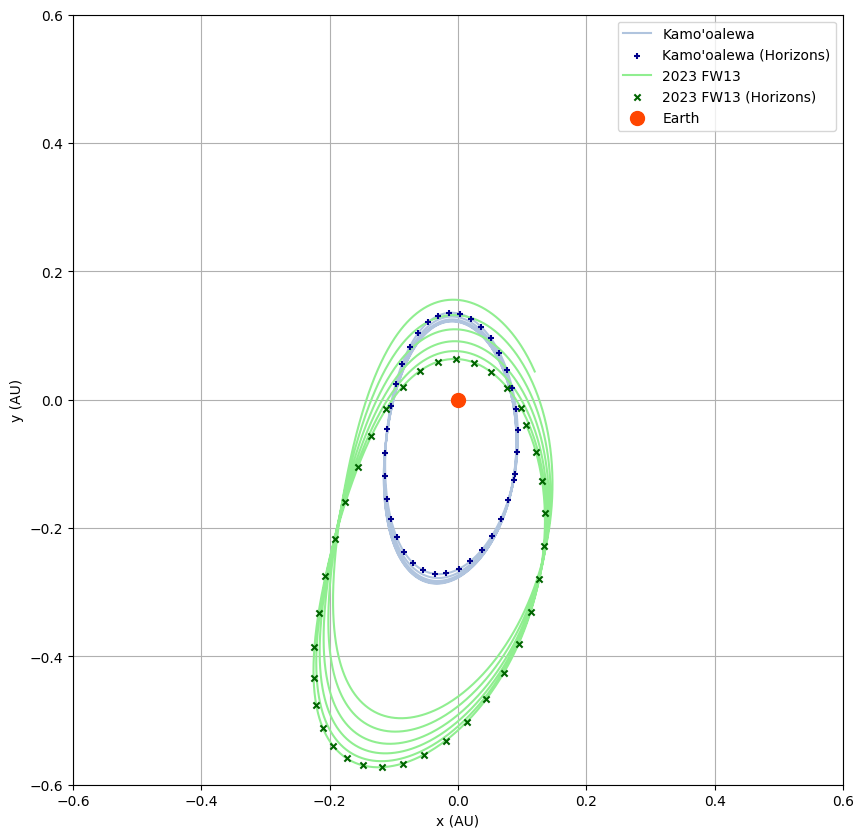

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(x_k_rot, y_k_rot, label='Kamo\'oalewa', color='lightsteelblue')
ax.scatter(x_k_rot_real, y_k_rot_real, label='Kamo\'oalewa (Horizons)', color='darkblue', marker='+', s=20, zorder=5)

ax.plot(x_f_rot, y_f_rot, label='2023 FW13', color='lightgreen')
ax.scatter(x_f_rot_real, y_f_rot_real, label='2023 FW13 (Horizons)', color='darkgreen', marker='x', s=20, zorder=5)

ax.scatter(0, 0, label='Earth', color='orangered', s=100, zorder=5)

ax.axis("square")
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-0.6, 0.6)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True)
plt.show()